<a href="https://colab.research.google.com/github/Naksh7Gupta/AutomateX/blob/main/DiffusionModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math # Added for sinusoidal positional encoding

device = "cuda" if torch.cuda.is_available() else "cpu"

T = 300
beta_start = 1e-4
beta_end = 0.02
img_size = 32 # Changed for CIFAR-10
batch_size = 128

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# Helper classes for the UNet
class PositionalEncoding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        # Sinusoidal positional encoding
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=time.device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, num_groups=8):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(num_groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups, out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t_emb):
        h = self.relu(self.norm1(self.conv1(x)))
        t_emb = self.relu(self.time_mlp(t_emb)) # Apply ReLU to time embedding
        # Add time embedding after first conv and normalization, reshape for broadcasting
        h = h + t_emb[:, :, None, None] # Broadcast time embedding across spatial dimensions
        h = self.relu(self.norm2(self.conv2(h)))
        return h

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.block = Block(in_ch, out_ch, time_emb_dim)
        self.pool = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=2, padding=1) # Using Conv2d for downsampling

    def forward(self, x, t_emb):
        x = self.block(x, t_emb)
        return self.pool(x), x # Return both pooled and original for skip connection

class UpBlock(nn.Module):
    def __init__(self, in_ch_from_lower, in_ch_from_skip_connection, out_ch, time_emb_dim):
        super().__init__()
        # in_ch_from_lower: channels from the layer below (e.g., x_mid)
        # in_ch_from_skip_connection: channels from the skip connection (e.g., skip2)
        # out_ch: output channels of this UpBlock's main block after concatenation
        self.upsample = nn.ConvTranspose2d(in_ch_from_lower, in_ch_from_skip_connection, 2, stride=2) # Upsample to match skip channels
        self.block = Block(in_ch_from_skip_connection * 2, out_ch, time_emb_dim) # Block takes concatenated channels

    def forward(self, x, skip_x, t_emb):
        x = self.upsample(x)
        x = torch.cat([x, skip_x], dim=1) # Concatenate skip connection
        return self.block(x, t_emb)

class UNet(nn.Module):
    def __init__(self, img_channels=1, base_channels=32, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            PositionalEncoding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.ReLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        self.inc = nn.Conv2d(img_channels, base_channels, 3, padding=1)

        self.down1 = DownBlock(base_channels, base_channels * 2, time_emb_dim)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4, time_emb_dim)

        self.mid = Block(base_channels * 4, base_channels * 4, time_emb_dim) # Bottleneck block

        # UpBlock(in_ch_from_lower, in_ch_from_skip_connection, out_ch, time_emb_dim)
        # For up2: x_mid (base_channels*4 ch), skip2 (base_channels*4 ch), output (base_channels*2 ch)
        self.up2 = UpBlock(base_channels * 4, base_channels * 4, base_channels * 2, time_emb_dim)
        # For up1: x_up2 (base_channels*2 ch), skip1 (base_channels*2 ch), output (base_channels ch)
        self.up1 = UpBlock(base_channels * 2, base_channels * 2, base_channels, time_emb_dim)

        self.outc = nn.Conv2d(base_channels, img_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x1 = self.inc(x)
        x_down1, skip1 = self.down1(x1, t_emb) # Returns (pooled, original)
        x_down2, skip2 = self.down2(x_down1, t_emb)

        x_mid = self.mid(x_down2, t_emb)

        x_up2 = self.up2(x_mid, skip2, t_emb)
        x_up1 = self.up1(x_up2, skip1, t_emb)

        return self.outc(x_up1)

model = UNet(img_channels=3, base_channels=32, time_emb_dim=256).to(device) # Instantiated UNet for CIFAR-10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Changed for 3 channels
])

dataset = datasets.CIFAR10(root="./data2", train=True, download=True, transform=transform) # Changed to CIFAR-10
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [38]:
def add_noise(x, t):
    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None, None, None]
    sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat[t])[:, None, None, None]
    noise = torch.randn_like(x)
    return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * noise, noise


epochs = 15

for epoch in range(epochs+6,epochs+7):
    for i, (images, _) in enumerate(dataloader):
        images = images.to(device)

        t = torch.randint(0, T, (images.size(0),), device=device)
        x_t, noise = add_noise(images, t)

        noise_pred = model(x_t, t)
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} Loss: {loss.item()}")

Epoch 17 Loss: 0.06776772439479828
Epoch 18 Loss: 0.06374093890190125
Epoch 19 Loss: 0.06830038875341415
Epoch 20 Loss: 0.06640841066837311
Epoch 21 Loss: 0.05851605162024498


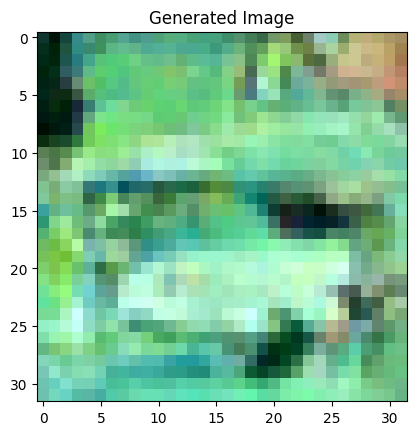

In [39]:
@torch.no_grad()
def sample():
    x = torch.randn((1, 3, img_size, img_size)).to(device)

    for t in reversed(range(T)):
        t_tensor = torch.tensor([t], device=device)

        noise_pred = model(x, t_tensor)

        alpha = alphas[t]
        alpha_hat_t = alpha_hat[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_hat_t)) * noise_pred
        ) + torch.sqrt(beta) * noise

    return x

# =========================
# Generate Image
# =========================
sampled_img = sample().cpu().squeeze()
# De-normalize and transpose for matplotlib if necessary
sampled_img = (sampled_img * 0.5) + 0.5 # Assuming normalization was to [-1, 1]
sampled_img = sampled_img.clamp(0, 1) # Clip values to [0, 1] range
plt.imshow(sampled_img.permute(1, 2, 0))
plt.title("Generated Image")
plt.show()

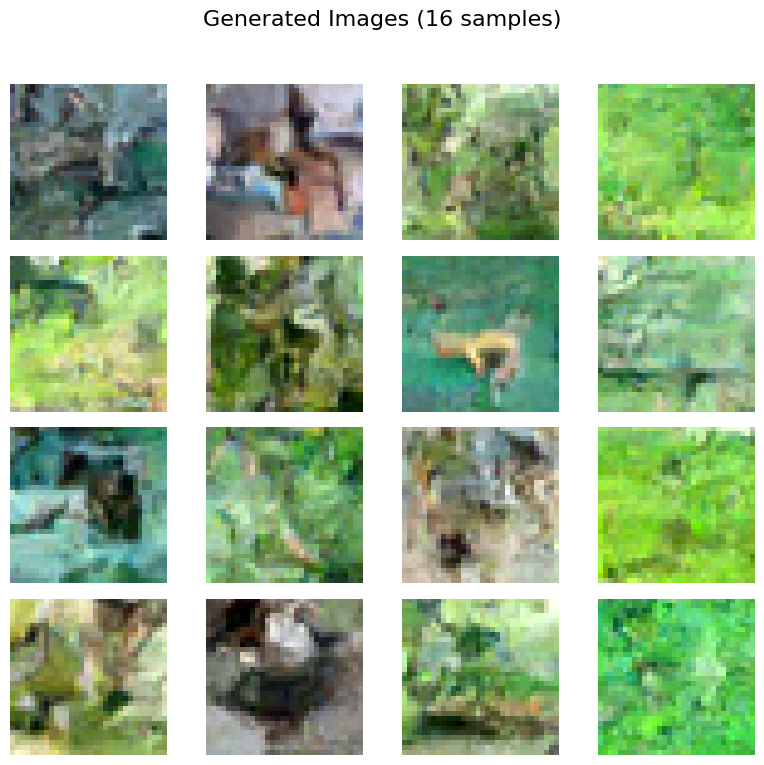

In [40]:
@torch.no_grad()
def sample_multiple(num_samples):
    sampled_images = []
    for _ in range(num_samples):
        x = torch.randn((1, 3, img_size, img_size)).to(device)

        for t in reversed(range(T)):
            t_tensor = torch.tensor([t], device=device)
            noise_pred = model(x, t_tensor)

            alpha = alphas[t]
            alpha_hat_t = alpha_hat[t]
            beta = betas[t]

            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = (1 / torch.sqrt(alpha)) * (
                x - ((1 - alpha) / torch.sqrt(1 - alpha_hat_t)) * noise_pred
            ) + torch.sqrt(beta) * noise

        # De-normalize and transpose for matplotlib if necessary
        img_to_display = (x.cpu().squeeze() * 0.5) + 0.5 # Assuming normalization was to [-1, 1]
        img_to_display = img_to_display.clamp(0, 1) # Clip values to [0, 1] range
        sampled_images.append(img_to_display)
    return sampled_images

# Generate and display a grid of sampled digits
num_images = 16
sampled_digits = sample_multiple(num_images)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sampled_digits[i].permute(1, 2, 0)) # Transpose for 3-channel images (C, H, W -> H, W, C)
    ax.axis('off')

plt.suptitle(f'Generated Images ({num_images} samples)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [42]:
!echo "# Diffusion-Model" >> README.md
!git init
!git add README.md
!git commit -m "first commit"
!git branch -M main
!git remote add origin https://github.com/Naksh7Gupta/Diffusion-Model.git
!git push -u origin main

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@14ee1b1bf1d5.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Naksh7Gupta/Diffusion-Model.git

In [43]:
!git remote add origin https://github.com/Naksh7Gupta/Diffusion-Model.git
!git branch -M main
!git push -u origin main

error: remote origin already exists.
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Naksh7Gupta/Diffusion-Model.git'
